# 15.综合 机制与学习模型的独立比较

## 学习目标与先修知识

在同一独立条件下比较计算图（computational graph）梯度（gradient）、连续方程、损失分项和混合修正，并说明证据范围。

先修：本篇 15.1—15.5；第 14 篇的独立模型（model）验证。

## 具体问题

人工清除系统给出一组已知机制与有限观测（observation）。一种小型学习修正改善了拟合，怎样依次检查梯度、数值步长、方程约束和新输入（input）预测？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先比较同一总量下的机制变化率与修正变化率。

In [2]:
x,u,k,theta=.8,.4,.4,-.1
print("机制率、修正率：",u-k*x,theta*np.tanh(x))

机制率、修正率： 0.07999999999999996 -0.0664036770267849


## 模型假设

总量单位 U，时间单位 T。初态、输入、观测与评价时段固定；训练条件是恒定输入 0.4 U/T，独立条件是 0.8 U/T。修正幅度与数据来源公开。人工生成的真参数（parameter）只用于最终核验，不让候选方法读取。

## 数学解释与推导

对神经元预测使用链式法则（chain rule）；对连续清除方程的梯度先有解析值，再分别核对 Euler 程序与伴随。数据损失、方程残差（residual）和初值（initial condition）损失各用自身尺度。混合右端为 $u-kx+\theta\tanh(x/s)$；当 $\theta=0$ 恢复机制基线。同形修正 $\theta x$ 只能识别 $k-\theta$，不能由新输入独自拆分。

## 核心实现

复用前面逐步展示过的透明函数。

In [3]:
def scalar_loss_grad(x, y, w, b, v, c):
    z = w * x + b
    a = math.tanh(z)
    prediction = v * a + c
    error = prediction - y
    factor = error * v * (1 - a * a)
    return prediction, .5 * error * error, [factor * x, factor, error * a, error]


def euler_forward_sensitivity(x0, k, h, steps):
    """Return state and dx/dk for the *discretized* Euler program."""
    states, sensitivity = [float(x0)], [0.]
    for _ in range(steps):
        x, s = states[-1], sensitivity[-1]
        states.append((1-k*h)*x)
        sensitivity.append((1-k*h)*s-h*x)
    return states, sensitivity


def continuous_loss_gradient(x0, k, observations):
    """Exact continuous-observation objective and its derivative."""
    loss, gradient = 0., 0.
    for t, y in observations:
        x = x0*math.exp(-k*t)
        residual = x-y
        loss += .5*residual*residual
        gradient -= t*x*residual
    return loss, gradient


def hybrid_rhs(x, u, k, theta, scale):
    return float(u-k*x+theta*math.tanh(x/scale))


def hybrid_euler(x0, inputs, h, k, theta, scale):
    states = [float(x0)]
    for u in inputs:
        states.append(states[-1]+h*hybrid_rhs(states[-1],float(u),k,theta,scale))
    return states


def scaled_total_loss(parts, data_scale, physics_scale, boundary_scale, weights):
    scales = [data_scale,physics_scale,boundary_scale]
    return float(sum(w*(value/(scale*scale)) for value,scale,w
                     in zip(parts,scales,weights)))


def rollout_metrics(truth, prediction):
    """Exclude the shared initial state from the mean squared rollout error."""
    diff = np.asarray(prediction[1:],dtype=float)-np.asarray(truth[1:],dtype=float)
    return [float(np.mean(diff*diff)),float(abs(diff[-1]))]

## 对照实验

在相同初值、输入和 Euler 网格上比较机制与混合候选。

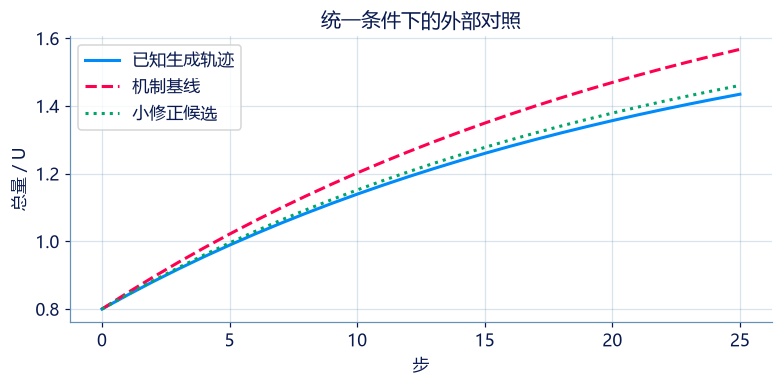

基线和候选误差： [0.007179625841996225, 0.13270869530161566] [0.0002771005669949284, 0.026006528147253016]


In [4]:
h=.1;inputs=[.8]*25;x0=.8;k=.4;scale=1.;truth=np.array(hybrid_euler(x0,inputs,h,k,-.1,scale));mechanism=np.array(hybrid_euler(x0,inputs,h,k,0.,scale));candidate=np.array(hybrid_euler(x0,inputs,h,k,-.08,scale))
fig,ax=plt.subplots(figsize=(7,3.4));ax.plot(truth,label="已知生成轨迹",color=BLUE);ax.plot(mechanism,"--",label="机制基线",color=PINK);ax.plot(candidate,":",label="小修正候选",color=GREEN);ax.set(xlabel="步",ylabel="总量 / U",title="统一条件下的外部对照");ax.legend();ax.grid(alpha=.25);plt.show()
print("基线和候选误差：",rollout_metrics(truth,mechanism),rollout_metrics(truth,candidate))

## 结果解释

当前有限人工条件下，小修正降低了预测误差。这仍不确定修正的真实机制身份；模型偏差、参数不可辨识和求解误差要分开报告。

### 独立核对

用零修正恒等式和解析清除模型检验实现。

In [5]:
np.testing.assert_allclose(hybrid_euler(.8,[.4]*2,.1,.4,0.,1.),[.8,.808,.81568])
loss,grad=continuous_loss_gradient(1.,.5,[(1.,.7)])
x=np.exp(-.5);np.testing.assert_allclose([loss,grad],[.5*(x-.7)**2,-(x-.7)*x])
assert rollout_metrics(truth,candidate)[0]<rollout_metrics(truth,mechanism)[0]
print("零修正、解析梯度和独立条件误差核验通过。")

零修正、解析梯度和独立条件误差核验通过。


## 练习与参考资料

先独立作答，再提交核对。

本篇综合题按基础辨析、方法应用、综合验证、迁移挑战递进，共 100 分。每题独立作答；正确选择或完整测试通过得该题全部分值。网页分别汇总首次作答分与练习达成分，支持按层次和学习目标复习。

### 第 1 题 · 基础辨析 · 10 分 · 单项选择题：综合：先声明梯度对象

有限 Euler 程序的反传与连续伴随在粗步长不一致，哪项处理正确？

- **A.** 先分别用离散差分和解析连续导数（derivative）核验，再研究细化。
- **B.** 判定其中一种方法必错。
- **C.** 把梯度（gradient）差直接解释为观测（observation）噪声。
- **D.** 在留出结果上调到一致后宣称独立验证。

[作答：综合：先声明梯度对象](http://127.0.0.1:8000/parts/15-%E5%8F%AF%E5%BE%AE%E5%88%86%E5%BB%BA%E6%A8%A1%E4%B8%8E%E6%9C%BA%E5%88%B6%E8%9E%8D%E5%90%88/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p15-capstone-gradient-object)

### 第 2 题 · 基础辨析 · 10 分 · 单项选择题：综合：机制参数是否可辨

只观测（observation） x，而方程仅含 k-θ；哪种新增信息能区分两参数（parameter）？

- **A.** 同一总量的更多时间点。
- **B.** 独立清除通量 kx 的测量。
- **C.** 把输入（input）曲线颜色改为绿色。
- **D.** 只把 Euler 步长减半。

[作答：综合：机制参数是否可辨](http://127.0.0.1:8000/parts/15-%E5%8F%AF%E5%BE%AE%E5%88%86%E5%BB%BA%E6%A8%A1%E4%B8%8E%E6%9C%BA%E5%88%B6%E8%9E%8D%E5%90%88/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p15-capstone-identifiability)

### 第 3 题 · 方法应用 · 15 分 · Python 计算题：综合：网络预测与梯度

按固定小网络返回预测、损失和 w,b,v,c 梯度（gradient）。

**函数与代码模板**

```python
def solve(
    x: float,
    y: float,
    w: float,
    b: float,
    v: float,
    c: float,
) -> tuple[float, float, list[float]]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x` | `float` | 状态（state）输入（input）。 | U |
| `y` | `float` | 目标率。 | U/T |
| `w` | `float` | 输入权重。 | 1 |
| `b` | `float` | 偏置。 | 1 |
| `v` | `float` | 输出（output）幅度。 | U/T |
| `c` | `float` | 输出偏置。 | U/T |

**返回值**

按以下顺序返回元组：(prediction, loss, gradient)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `prediction` | `float` | 预测率。 | U/T |
| `loss` | `float` | 半平方误差。 | (U/T)^2 |
| `gradient` | `list[float]` | 四个参数（parameter）导数（derivative）。 | 按参数 |

**计算规则**

预测同上，损失 = (预测-y)²/2；梯度按 w,b,v,c 顺序。

**约束与边界**

- 输入规模不超过100，全部数值有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x | 状态（state）输入（input）。 | 1 | U |
| y | 目标率。 | 0.2 | U/T |
| w | 输入权重。 | 0.5 | 1 |
| b | 偏置。 | 0.1 | 1 |
| v | 输出（output）幅度。 | 0.8 | U/T |
| c | 输出偏置。 | 0 | U/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x = 1.0
y = 0.2
w = 0.5
b = 0.1
v = 0.8
c = 0.0

result = solve(x, y, w, b, v, c)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| prediction | 预测率。 | ≈ 0.4296397 | U/T |
| loss | 半平方误差。 | ≈ 0.02636719 | (U/T)^2 |
| gradient | 四个参数（parameter）导数（derivative）。 | [0.13072517672709957, 0.13072517672709957, 0.12332787653061471, 0.22963965359842825] | 按参数 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.42963965359842826,
                   0.02636718525240306,
                   [0.13072517672709957,
                    0.13072517672709957,
                    0.12332787653061471,
                    0.22963965359842825])
```

**样例解释**

先对预测求误差，再反向应用 tanh 的导数。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：综合：网络预测与梯度](http://127.0.0.1:8000/parts/15-%E5%8F%AF%E5%BE%AE%E5%88%86%E5%BB%BA%E6%A8%A1%E4%B8%8E%E6%9C%BA%E5%88%B6%E8%9E%8D%E5%90%88/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p15-capstone-small-gradient)

### 第 4 题 · 方法应用 · 15 分 · Python 计算题：综合：连续方程的离散梯度

固定 Euler 步数并返回完整状态（state）与参数（parameter）灵敏度路径。

**函数与代码模板**

```python
def solve(
    x0: float,
    k: float,
    h: float,
    steps: int,
) -> tuple[list[float], list[float]]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x0` | `float` | 固定初态。 | U |
| `k` | `float` | 清除率。 | 1/T |
| `h` | `float` | 步长。 | T |
| `steps` | `int` | 更新次数。 | 步 |

**返回值**

按以下顺序返回元组：(states, sensitivity)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[float]` | 状态路径。 | U |
| `sensitivity` | `list[float]` | 对 k 的路径导数（derivative）。 | U·T |

**计算规则**

初始 s=0；每步 x_new=(1-k*h)*x，s_new=(1-k*h)*s-h*x；返回两条含初值（initial condition）路径。

**约束与边界**

- x0≥0，k≥0，h>0，0≤steps≤100 且 k*h<1。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x0 | 固定初态。 | 1.5 | U |
| k | 清除率。 | 0.4 | 1/T |
| h | 步长。 | 0.1 | T |
| steps | 更新次数。 | 3 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x0 = 1.5
k = 0.4
h = 0.1
steps = 3

result = solve(x0, k, h, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 状态路径。 | [1.5, 1.44, 1.3823999999999999, 1.3271039999999998] | U |
| sensitivity | 对 k 的路径导数（derivative）。 | [0.0, -0.15000000000000002, -0.28800000000000003, -0.41472] | U·T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([1.5,
                    1.44,
                    1.3823999999999999,
                    1.3271039999999998],
                   [0.0,
                    -0.15000000000000002,
                    -0.28800000000000003,
                    -0.41472])
```

**样例解释**

递推灵敏度应随每个 Euler 更新一起推进。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：综合：连续方程的离散梯度](http://127.0.0.1:8000/parts/15-%E5%8F%AF%E5%BE%AE%E5%88%86%E5%BB%BA%E6%A8%A1%E4%B8%8E%E6%9C%BA%E5%88%B6%E8%9E%8D%E5%90%88/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p15-capstone-forward-gradient)

### 第 5 题 · 综合验证 · 15 分 · Python 计算题：综合：已声明尺度的方程损失

给定三项原始损失、对应正尺度及非负权重，返回缩放后加权总损失。

**函数与代码模板**

```python
def solve(
    parts: list[float],
    data_scale: float,
    physics_scale: float,
    boundary_scale: float,
    weights: list[float],
) -> float:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `parts` | `list[float]` | 依次为数据、方程、初边值原始平方损失。 | 按分项 |
| `data_scale` | `float` | 数据残差（residual）尺度。 | U |
| `physics_scale` | `float` | 方程残差尺度。 | U/T |
| `boundary_scale` | `float` | 初边值残差尺度。 | U |
| `weights` | `list[float]` | 三项非负权重。 | 1 |

**返回值**

直接返回 total（float）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `total` | `float` | 无量纲（dimensionless）加权损失。 | 1 |

**计算规则**

每项先除以各自残差尺度的平方，再乘对应权重并求和。

**约束与边界**

- parts 和 weights 各恰有三项；三个尺度正，损失和权重非负。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| parts | 依次为数据、方程、初边值原始平方损失。 | [4.0, 9.0, 1.0] | 按分项 |
| data_scale | 数据残差（residual）尺度。 | 2 | U |
| physics_scale | 方程残差尺度。 | 3 | U/T |
| boundary_scale | 初边值残差尺度。 | 1 | U |
| weights | 三项非负权重。 | [1.0, 1.0, 1.0] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
parts = [4.0, 9.0, 1.0]
data_scale = 2.0
physics_scale = 3.0
boundary_scale = 1.0
weights = [1.0, 1.0, 1.0]

result = solve(parts, data_scale, physics_scale, boundary_scale, weights)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| total | 无量纲（dimensionless）加权损失。 | 3 | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = 3.0
```

**样例解释**

首例三项缩放后均为1，总损失为3。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：综合：已声明尺度的方程损失](http://127.0.0.1:8000/parts/15-%E5%8F%AF%E5%BE%AE%E5%88%86%E5%BB%BA%E6%A8%A1%E4%B8%8E%E6%9C%BA%E5%88%B6%E8%9E%8D%E5%90%88/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p15-capstone-scaled-loss)

### 第 6 题 · 综合验证 · 15 分 · Python 计算题：综合：相同留出轨迹下的误差

输入（input）相同条件下真实和候选路径，计算后续步均方和终点绝对误差。

**函数与代码模板**

```python
def solve(
    truth: list[float],
    prediction: list[float],
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `truth` | `list[float]` | 独立条件的真值轨迹（trajectory）。 | U |
| `prediction` | `list[float]` | 候选轨迹。 | U |

**返回值**

直接返回 metrics（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `metrics` | `list[float]` | 后续步 MSE、终点绝对误差。 | U²、U |

**计算规则**

忽略相同初态；MSE = 后续各步差值平方的平均，终点绝对误差为末项差的绝对值。

**约束与边界**

- 两条路径等长，至少含一个后续状态（state），全部有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| truth | 独立条件的真值轨迹（trajectory）。 | [1.0, 0.8, 0.6, 0.5] | U |
| prediction | 候选轨迹。 | [1.0, 0.9, 0.7, 0.4] | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
truth = [1.0, 0.8, 0.6, 0.5]
prediction = [1.0, 0.9, 0.7, 0.4]

result = solve(truth, prediction)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| metrics | 后续步 MSE、终点绝对误差。 | [0.009999999999999995, 0.09999999999999998] | U²、U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.009999999999999995,
                   0.09999999999999998]
```

**样例解释**

不要把相同初态作为额外一个误差样本稀释结果。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：综合：相同留出轨迹下的误差](http://127.0.0.1:8000/parts/15-%E5%8F%AF%E5%BE%AE%E5%88%86%E5%BB%BA%E6%A8%A1%E4%B8%8E%E6%9C%BA%E5%88%B6%E8%9E%8D%E5%90%88/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p15-capstone-independent-error)

### 第 7 题 · 迁移挑战 · 10 分 · 单项选择题：综合：改变求解步长

用粗步长训练连续右端，细化时预测和梯度（gradient）改变，应先做什么？

- **A.** 断言真实机制随步长改变。
- **B.** 忽略步长变化，只报告训练损失。
- **C.** 固定模型（model）参数（parameter），核查状态（state）与梯度网格收敛，再评估新初值（initial condition）。
- **D.** 把细网格留出结果重新用于参数选择。

[作答：综合：改变求解步长](http://127.0.0.1:8000/parts/15-%E5%8F%AF%E5%BE%AE%E5%88%86%E5%BB%BA%E6%A8%A1%E4%B8%8E%E6%9C%BA%E5%88%B6%E8%9E%8D%E5%90%88/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p15-capstone-grid-transfer)

### 第 8 题 · 迁移挑战 · 10 分 · 单项选择题：综合：混合修正的证据

去掉修正后新输入（input）误差增加，但只测 x 且修正与清除同形。能支持什么？

- **A.** 已唯一发现新的生理通道。
- **B.** 所有输入范围都必更好。
- **C.** 任何机制模型（model）都不需要。
- **D.** 该条件下修正改善预测；机制归属仍需独立观测（observation）或干预。

[作答：综合：混合修正的证据](http://127.0.0.1:8000/parts/15-%E5%8F%AF%E5%BE%AE%E5%88%86%E5%BB%BA%E6%A8%A1%E4%B8%8E%E6%9C%BA%E5%88%B6%E8%9E%8D%E5%90%88/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p15-capstone-hybrid-ablation)

**进一步阅读**

[自动微分综述](https://jmlr.org/papers/volume18/17-468/17-468.pdf)、[Neural ODE 原论文](https://papers.nips.cc/paper_files/paper/2018/file/69386f6bb1dfed68692a24c8686939b9-Paper.pdf)、[PINN 原论文](https://www.sciencedirect.com/science/article/pii/S0021999118307125)。